# Part 1a - Real life examples

**Conceptual Explanations**
- _Confounder_: A variable that influences both the treatment/exposure and the outcome, creating a spurious association between them. If not controlled for, it leads to biased causal estimates because it provides an alternative pathway between treatment and outcome.
- _Collider_: A variable that is influenced by both the treatment and outcome (or their causes). Conditioning on a collider creates spurious associations between its causes, even when they are actually independent.
- _Mediatior_: A variable that lies on the causal pathway between treatment and outcome. The treatment affects the mediator, which in turn affects the outcome, representing one mechanism through which the treatment works.
 
**Economic Examples**
1. Confounder: Education and Wages

Variables:  
>Treatment: College degree (binary)  
>Outcome: Wages (continuous)  
>Confounder: Family socioeconomic status (continuous)

Family socioeconomic status affects both the likelihood of obtaining a college degree (wealthier families can afford education) and wages (through networks, cultural capital, etc.).

2. Collider: Job Performance Evaluation

Variables:  
>Cause 1: Actual productivity (continuous)  
>Cause 2: Office politics skills (continuous)  
>Collider: Performance evaluation score (continuous)  

Both actual productivity and office politics skills influence performance evaluations. If we only study workers who received high evaluations (conditioning on the collider), we might find a negative correlation between productivity and politics skills.

3. Mediation: Minimum Wage and Employment

Variables:  
>Treatment: Minimum wage increase (continuous)  
>Mediator: Labor costs (continuous)  
>Outcome: Employment levels (continuous)  

Minimum wage increases affect employment through increased labor costs (the mediator).

In [5]:
import os
from graphviz import Digraph

# Carpeta de salida
output_dir = "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/"
os.makedirs(output_dir, exist_ok=True)

def export_dag(nodes, edges, filename):
    dot = Digraph(format="png")
    dot.attr(rankdir="LR")
    for node, attrs in nodes.items():
        dot.node(node, **attrs)
    for edge in edges:
        dot.edge(*edge)
    dot.render(os.path.join(output_dir, filename), cleanup=True)

# -------------------------
# Example 1: Confounder
# -------------------------
nodes_conf = {
    "X": {"label": "Education"},
    "Y": {"label": "Wages"},
    "Z": {"label": "Ability", "shape": "ellipse", "color": "blue"}
}
edges_conf = [("Z", "X"), ("Z", "Y"), ("X", "Y")]
export_dag(nodes_conf, edges_conf, "confounder")

# -------------------------
# Example 2: Collider
# -------------------------
nodes_coll = {
    "X": {"label": "Education"},
    "Y": {"label": "Family Wealth"},
    "Z": {"label": "Prestigious Job", "shape": "ellipse", "color": "blue"}
}
edges_coll = [("X", "Z"), ("Y", "Z"), ("X", "Y")]
export_dag(nodes_coll, edges_coll, "collider")

# -------------------------
# Example 3: Mediator
# -------------------------
nodes_med = {
    "X": {"label": "Education"},
    "Y": {"label": "Wages"},
    "M": {"label": "Skills", "shape": "ellipse", "color": "blue"}
}
edges_med = [("X", "M"), ("M", "Y"), ("X", "Y")]
export_dag(nodes_med, edges_med, "mediator")


# Part 1b - Simpson's paradox 

**Conceptual Explanation**  
Simpson’s paradox arises when a trend that appears within different subgroups reverses or disappears when the data are combined. This happens because of the influence of a lurking or confounding variable that changes the interpretation of the relationship between the explanatory variable and the outcome.

**Economic example:**
Consider two universities with different admission rates. Within each university, women have equal or higher acceptance probabilities compared to men. However, when the data from both universities are pooled together, it looks as if men have a higher acceptance rate. This reversal of the association is Simpson’s paradox.

C:\Users\VICTOR\AppData\Local\Temp\ipykernel_30924\175867708.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pooled:    intercept = {:.4f}, slope = {:.4f}".format(m_all.params[0], m_all.params[1]))
C:\Users\VICTOR\AppData\Local\Temp\ipykernel_30924\175867708.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Group A:   intercept = {:.4f}, slope = {:.4f}".format(m_A.params[0], m_A.params[1]))
C:\Users\VICTOR\AppData\Local\Temp\ipykernel_30924\175867708.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labe

Pooled:    intercept = 11.3238, slope = -1.9330
Group A:   intercept = 9.9456, slope = 0.9873
Group B:   intercept = -5.1084, slope = 1.0289


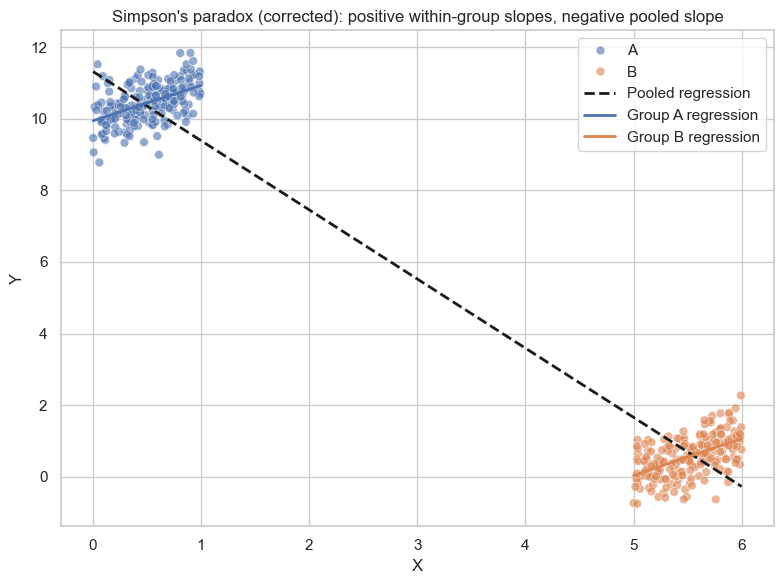

Saved plot to: C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/simpsons_paradox_corrected.png


In [7]:
# Corrected Simpson's paradox example (Python)
# Ensures positive slope within each group and negative pooled slope.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# reproducibilidad
np.random.seed(123)

# salida
output_dir = "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/"
os.makedirs(output_dir, exist_ok=True)

# ---- Simulación diseñada ----
n = 200

# Grupo A: X pequeño, intercepto alto -> Y grande
X_A = np.random.uniform(0.0, 1.0, n)
Y_A = 10.0 + 1.0 * X_A + np.random.normal(0, 0.5, n)   # pendiente positiva ~1

# Grupo B: X grande, intercepto muy bajo -> Y pequeño
X_B = np.random.uniform(5.0, 6.0, n)
Y_B = -5.0 + 1.0 * X_B + np.random.normal(0, 0.5, n)   # pendiente positiva ~1

df = pd.DataFrame({
    "X": np.concatenate([X_A, X_B]),
    "Y": np.concatenate([Y_A, Y_B]),
    "Group": ["A"] * n + ["B"] * n
})

# ---- Ajustes (OLS) ----
def fit_ols(x, y):
    Xc = sm.add_constant(x)
    m = sm.OLS(y, Xc).fit()
    return m

m_all = fit_ols(df["X"], df["Y"])
m_A = fit_ols(df.loc[df["Group"]=="A", "X"], df.loc[df["Group"]=="A", "Y"])
m_B = fit_ols(df.loc[df["Group"]=="B", "X"], df.loc[df["Group"]=="B", "Y"])

# imprimir coeficientes (intercept, slope)
print("Pooled:    intercept = {:.4f}, slope = {:.4f}".format(m_all.params[0], m_all.params[1]))
print("Group A:   intercept = {:.4f}, slope = {:.4f}".format(m_A.params[0], m_A.params[1]))
print("Group B:   intercept = {:.4f}, slope = {:.4f}".format(m_B.params[0], m_B.params[1]))

# ---- Plot ----
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))

# puntos
sns.scatterplot(data=df, x="X", y="Y", hue="Group", alpha=0.6, s=40, palette=["C0","C1"])

# líneas de regresión construidas a partir de coeficientes OLS
x_vals = np.linspace(df["X"].min(), df["X"].max(), 200)

# pooled
y_pooled = m_all.params[0] + m_all.params[1] * x_vals
plt.plot(x_vals, y_pooled, color="k", linestyle="--", linewidth=2, label="Pooled regression")

# group A line (plot only across group's X range)
xA_vals = np.linspace(df.loc[df["Group"]=="A","X"].min(), df.loc[df["Group"]=="A","X"].max(), 100)
yA_vals = m_A.params[0] + m_A.params[1] * xA_vals
plt.plot(xA_vals, yA_vals, color="C0", linewidth=2, label="Group A regression")

# group B line
xB_vals = np.linspace(df.loc[df["Group"]=="B","X"].min(), df.loc[df["Group"]=="B","X"].max(), 100)
yB_vals = m_B.params[0] + m_B.params[1] * xB_vals
plt.plot(xB_vals, yB_vals, color="C1", linewidth=2, label="Group B regression")

# true within-group slope line for reference (optional)
# plt.plot(xA_vals, 10.0 + 1.0 * xA_vals, color="C0", alpha=0.3)
# plt.plot(xB_vals, -5.0 + 1.0 * xB_vals, color="C1", alpha=0.3)

plt.legend()
plt.title("Simpson's paradox (corrected): positive within-group slopes, negative pooled slope")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()

# guardar
outfile = os.path.join(output_dir, "simpsons_paradox_corrected.png")
plt.savefig(outfile, dpi=300)
plt.show()
print("Saved plot to:", outfile)



# Part 2 - Can we omit some controls?

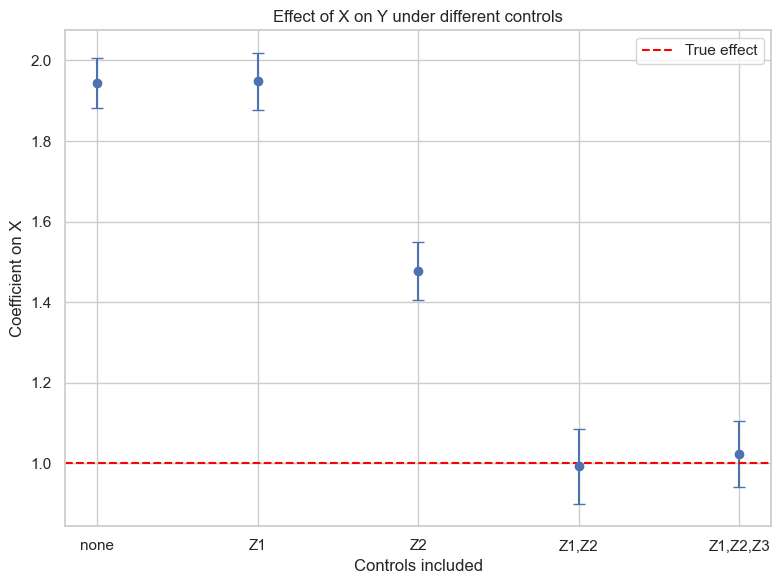

Saved plot to: C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/part2_coefficients.png

=== Regression (4): Y ~ X + Z1 + Z2 ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     2271.
Date:                Sat, 27 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:15:07   Log-Likelihood:                -1831.7
No. Observations:                1000   AIC:                             3671.
Df Residuals:                     996   BIC:                             3691.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [8]:
# Part 2 - Can we omit some controls? (Python)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# reproducibilidad
np.random.seed(123)

# carpeta de salida
output_dir = "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# Simulación del DAG
# -------------------------------
n = 1000

# variables exógenas
Z1 = np.random.normal(0, 1, n)
Z3 = np.random.normal(0, 1, n)
U2 = np.random.normal(0, 1, n)

# relaciones
Z2 = Z3 + np.random.normal(0, 1, n)   # Z3 -> Z2
X = Z1 + Z2 + np.random.normal(0, 1, n)  # Z1,Z2 -> X
Y = X + Z1 + Z2 + Z3 + U2 + np.random.normal(0, 1, n)  # todos afectan Y

# dataset
dat = pd.DataFrame({"X":X, "Y":Y, "Z1":Z1, "Z2":Z2, "Z3":Z3})

# -------------------------------
# Función para correr OLS
# -------------------------------
def run_reg(y, Xvars, data):
    X = sm.add_constant(data[Xvars])
    model = sm.OLS(data[y], X).fit()
    return model

# -------------------------------
# Estimaciones
# -------------------------------
results = {}

# 1. Y ~ X
results["none"] = run_reg("Y", ["X"], dat)

# 2. Y ~ X + Z1
results["Z1"] = run_reg("Y", ["X","Z1"], dat)

# 3. Y ~ X + Z2
results["Z2"] = run_reg("Y", ["X","Z2"], dat)

# 4. Y ~ X + Z1 + Z2
results["Z1,Z2"] = run_reg("Y", ["X","Z1","Z2"], dat)

# 5. Y ~ X + Z1 + Z2 + Z3
results["Z1,Z2,Z3"] = run_reg("Y", ["X","Z1","Z2","Z3"], dat)

# -------------------------------
# Extraer coef y ICs
# -------------------------------
estimates = []
for k, m in results.items():
    coef = m.params["X"]
    se = m.bse["X"]
    ci_low, ci_high = m.conf_int().loc["X"]
    estimates.append({
        "controls": k,
        "estimate": coef,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

df_est = pd.DataFrame(estimates)

# -------------------------------
# Gráfico de coeficientes
# -------------------------------
plt.figure(figsize=(8,6))
plt.errorbar(df_est["controls"], df_est["estimate"], 
             yerr=1.96*df_est["se"], fmt="o", capsize=4)
plt.axhline(1.0, color="red", linestyle="--", label="True effect")
plt.xlabel("Controls included")
plt.ylabel("Coefficient on X")
plt.title("Effect of X on Y under different controls")
plt.legend()
plt.tight_layout()

outfile = os.path.join(output_dir, "part2_coefficients.png")
plt.savefig(outfile, dpi=300)
plt.show()
print("Saved plot to:", outfile)

# -------------------------------
# Mostrar resúmenes de (4) y (5)
# -------------------------------
print("\n=== Regression (4): Y ~ X + Z1 + Z2 ===")
print(results["Z1,Z2"].summary())

print("\n=== Regression (5): Y ~ X + Z1 + Z2 + Z3 ===")
print(results["Z1,Z2,Z3"].summary())


When regressing Y on X with different sets of controls, we find the following:

Without controls, the estimate of the effect of X on Y is biased due to omitted variable confounding.

When controlling for Z1 and Z2 (Regression 4), the estimated coefficient on X is 0.993 (SE = 0.048), which is very close to the true causal effect of 1.

Adding Z3 as an additional control (Regression 5) further improves precision. The estimated coefficient becomes 1.023 (SE = 0.042), again correctly recovering the true effect.

Interpretation

The minimal sufficient adjustment set is {Z1, Z2}. Controlling for these two variables blocks the backdoor paths between X and Y, yielding an unbiased estimate of the causal effect.

Including Z3 is not strictly necessary for identification, but it helps reduce residual confounding noise and increases efficiency, as seen from the smaller standard error.

Conclusion:
You can obtain a good estimate of the causal effect by controlling for Z1 and Z2. Adding Z3 is optional but beneficial for precision.

# Part 3 - Damned if you do, damned if you don't 

In [11]:
import os
import numpy as np
import pandas as pd
from graphviz import Digraph
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Carpeta de salida
output_dir = "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/Python/Output/"
os.makedirs(output_dir, exist_ok=True)

# === DAG Example 4 ===
dag = Digraph(format="png")
dag.attr(size="6,6")

dag.node("U1")
dag.node("U2")
dag.node("Z")
dag.node("X")
dag.node("Y")

dag.edge("U1", "X")
dag.edge("U1", "Z")
dag.edge("U2", "Z")
dag.edge("U2", "Y")
dag.edge("X", "Y")

dag.render(output_dir + "DAG_example4", format="png", cleanup=True)

# === Simulación ===
np.random.seed(123)
n = 1000
U1 = np.random.normal(size=n)
U2 = np.random.normal(size=n)
X = U1 + np.random.normal(size=n)
Z = U1 + U2 + np.random.normal(size=n)
Y = X + U2 + np.random.normal(size=n)

dat = pd.DataFrame({"Y": Y, "X": X, "Z": Z, "U1": U1, "U2": U2})

# === Regressions ===
def run_regression(dep, indep, data):
    Xmat = sm.add_constant(data[indep])
    model = sm.OLS(data[dep], Xmat).fit()
    return model

reg1 = run_regression("Y", ["X"], dat)
reg2 = run_regression("Y", ["X", "Z"], dat)

# === Plot coefficients ===
coef_data = pd.DataFrame({
    "Model": ["Y ~ X", "Y ~ X + Z"],
    "Estimate": [reg1.params["X"], reg2.params["X"]],
    "SE": [reg1.bse["X"], reg2.bse["X"]]
})

plt.figure(figsize=(6,4))
plt.errorbar(coef_data["Model"], coef_data["Estimate"], 
             yerr=1.96*coef_data["SE"], fmt="o", capsize=5)
plt.axhline(y=1, color="red", linestyle="--", label="True effect = 1")
plt.ylabel("Coefficient of X")
plt.title("Effect of X on Y with/without controlling for Z")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir + "Part3a_coefficients.png", dpi=300)
plt.close()

# Mostrar resúmenes de las regresiones
print("=== Regression 1: Y ~ X ===")
print(reg1.summary())

print("\n=== Regression 2: Y ~ X + Z ===")
print(reg2.summary())

# También puedes imprimir la tabla resumida de coeficientes
print("\nCoefficients of X:")
print(coef_data)


=== Regression 1: Y ~ X ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     951.8
Date:                Sat, 27 Sep 2025   Prob (F-statistic):          2.60e-147
Time:                        21:18:16   Log-Likelihood:                -1733.6
No. Observations:                1000   AIC:                             3471.
Df Residuals:                     998   BIC:                             3481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0673   

In Regression (1), where we regress 
𝑌
Y only on 
𝑋
X, the estimated coefficient of 
𝑋
X is 0.97 (SE ≈ 0.031), which is close to the true causal effect of 1.

In Regression (2), when we additionally control for 
𝑍
Z, the coefficient of 
𝑋
X drops to 0.78 (SE ≈ 0.031). This bias appears because 
𝑍
Z is a collider: conditioning on it opens a spurious path between 
𝑋
X and 
𝑌
Y, which distorts the estimate.

Thus, the correct specification is Regression (1) without controlling for 
𝑍
Z. Controlling for 
𝑍
Z leads to a biased estimate, even though it increases 
𝑅
2
R
2
.

Answer to the question:

The best estimate of the causal effect comes from Regression (1).

Controlling for 
𝑍
Z worsens the estimate because it introduces collider bias.